In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


In [68]:
data = pd.read_excel("environmental_dataset.xlsx")

In [69]:
data.columns

Index(['Record_ID', 'Date', 'Temperature_C', 'Humidity_percent', 'Rainfall_mm',
       'Wind_Speed_kmh', 'PM2_5_ug_m3', 'PM10_ug_m3', 'NO2_ug_m3',
       'Air_Quality_Index_AQI', 'Green_Environmental_Index',
       'Air_Quality_Category'],
      dtype='object')

In [70]:
data.head()


,Record_ID,Date,Temperature_C,Humidity_percent,Rainfall_mm,Wind_Speed_kmh,PM2_5_ug_m3,PM10_ug_m3,NO2_ug_m3,Air_Quality_Index_AQI,Green_Environmental_Index,Air_Quality_Category
0,1,2025-01-01,28.7,78.9,0.0,8.3,31.7,53.5,29.6,83,53.3,Moderate
1,2,2025-01-02,21.3,83.7,2.7,13.7,17.8,60.9,11.0,55,70.0,Moderate
2,3,2025-01-03,31.1,59.4,0.0,11.7,33.9,52.4,25.4,71,66.6,Moderate
3,4,2025-01-04,32.2,52.0,0.0,10.8,21.1,73.9,34.0,86,69.2,Moderate
4,5,2025-01-05,16.3,58.6,8.9,10.5,18.1,40.5,20.4,32,65.6,Good


In [71]:
data.describe()

,Record_ID,Date,Temperature_C,Humidity_percent,Rainfall_mm,Wind_Speed_kmh,PM2_5_ug_m3,PM10_ug_m3,NO2_ug_m3,Air_Quality_Index_AQI,Green_Environmental_Index
count,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2025-09-07 12:00:00,26.928400,69.666000,1.997600,10.147200,26.434800,50.595000,25.703800,60.458000,63.813400
min,1.000000,2025-01-01 00:00:00,14.000000,38.300000,0.000000,1.000000,5.000000,10.800000,5.000000,20.000000,47.400000
25%,125.750000,2025-05-05 18:00:00,23.300000,63.200000,0.000000,7.900000,20.000000,41.000000,20.175000,49.000000,60.200000
50%,250.500000,2025-09-07 12:00:00,27.000000,69.700000,0.000000,10.000000,26.400000,50.150000,25.300000,60.000000,64.050000
75%,375.250000,2026-01-10 06:00:00,30.200000,76.300000,2.300000,12.425000,32.325000,60.025000,30.900000,72.000000,66.925000
max,500.000000,2026-05-15 00:00:00,42.000000,98.000000,35.000000,19.800000,55.300000,95.300000,57.900000,104.000000,80.400000
std,144.481833,NaN,5.260245,10.157683,4.139171,3.265698,9.074322,14.250844,8.178375,16.381237,5.040199


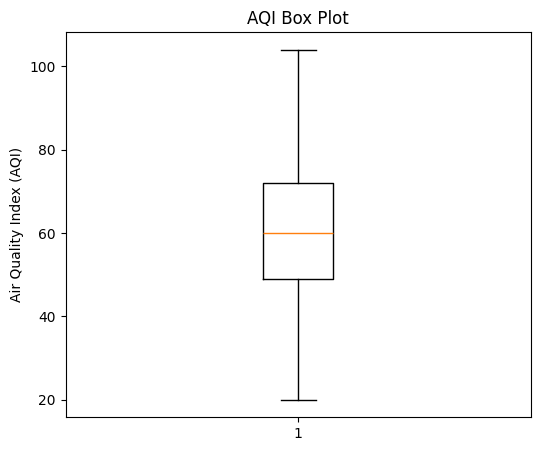

In [72]:
plt.figure(figsize=(6,5))

plt.boxplot(data["Air_Quality_Index_AQI"])

plt.ylabel("Air Quality Index (AQI)")
plt.title("AQI Box Plot")

plt.show()

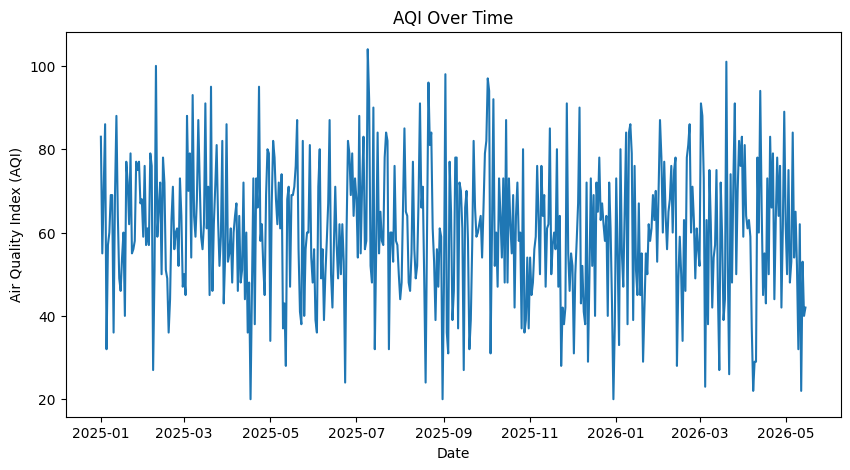

In [73]:
plt.figure(figsize=(10,5))

plt.plot(data["Date"], data["Air_Quality_Index_AQI"])

plt.xlabel("Date")
plt.ylabel("Air Quality Index (AQI)")
plt.title("AQI Over Time")

plt.show()

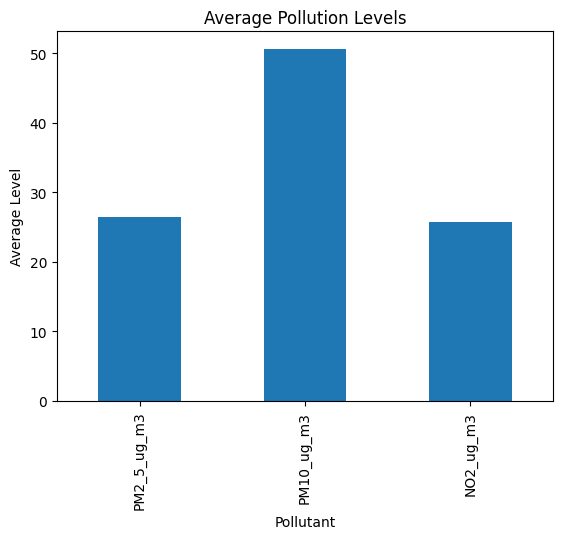

In [74]:
pollution = data[["PM2_5_ug_m3", "PM10_ug_m3", "NO2_ug_m3"]].mean()

pollution.plot(kind="bar")

plt.xlabel("Pollutant")
plt.ylabel("Average Level")
plt.title("Average Pollution Levels")

plt.show()

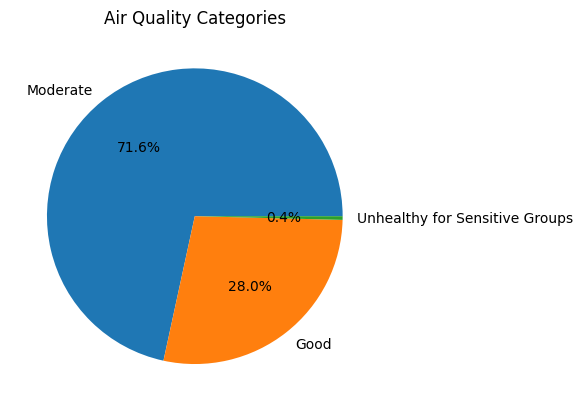

In [75]:
data["Air_Quality_Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Air Quality Categories")
plt.ylabel("")

plt.show()

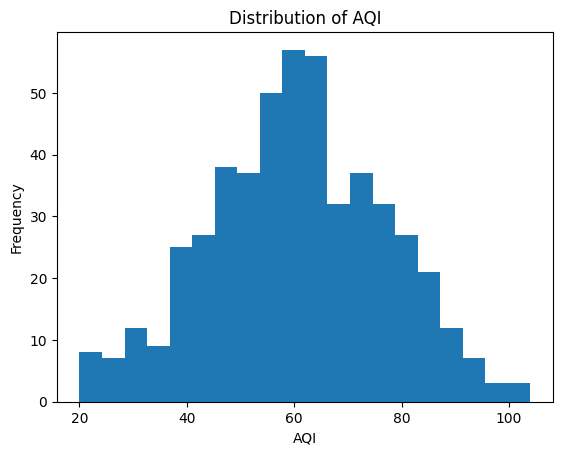

In [76]:
plt.hist(data["Air_Quality_Index_AQI"], bins=20)

plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of AQI")

plt.show()

In [77]:
X = data[["PM2_5_ug_m3"]]
Y = data["Air_Quality_Index_AQI"]
model = LinearRegression()
model.fit(X, Y)
slope = model.coef_[0]

print("Slope:", slope)

Slope: 1.221067604435731


In [78]:
intercept = model.intercept_

print("Intercept:", intercept)

Intercept: 28.179322090262332


In [79]:
r2 = model.score(X, Y)

print("R²:", r2)

R²: 0.4575245274586347


In [80]:
X_multiple = data[["PM2_5_ug_m3", "PM10_ug_m3", "NO2_ug_m3"]]

Y = data["Air_Quality_Index_AQI"]

In [81]:
multiple_model = LinearRegression()

In [82]:
X_multiple = data[["PM2_5_ug_m3", "PM10_ug_m3", "NO2_ug_m3"]]

Y = data["Air_Quality_Index_AQI"]

multiple_model = LinearRegression()

multiple_model.fit(X_multiple, Y)

multiple_r2 = multiple_model.score(X_multiple, Y)

print("R² Score:", multiple_r2)

R² Score: 0.6927393076381998


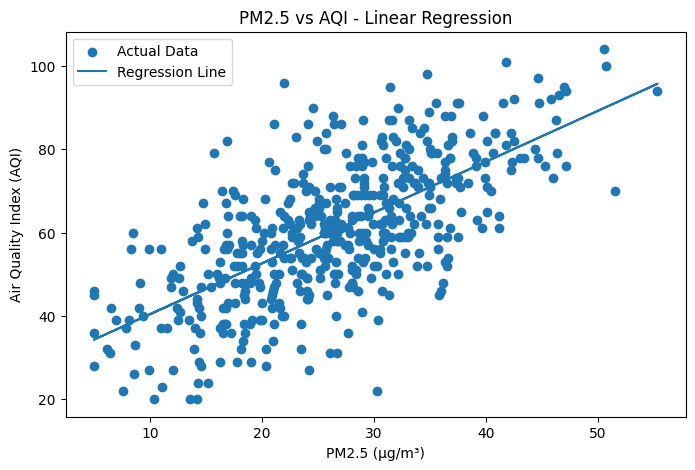

In [83]:
prediction = model.predict(X)

plt.figure(figsize=(8,5))

plt.scatter(X, Y, label="Actual Data")
plt.plot(X, prediction, label="Regression Line")

plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Air Quality Index (AQI)")
plt.title("PM2.5 vs AQI - Linear Regression")

plt.legend()
plt.show()

In [84]:
data["Predicted_AQI"] = prediction

data[["Air_Quality_Index_AQI", "Predicted_AQI"]].head()

,Air_Quality_Index_AQI,Predicted_AQI
0,83,66.887165
1,55,49.914325
2,71,69.573514
3,86,53.943849
4,32,50.280646


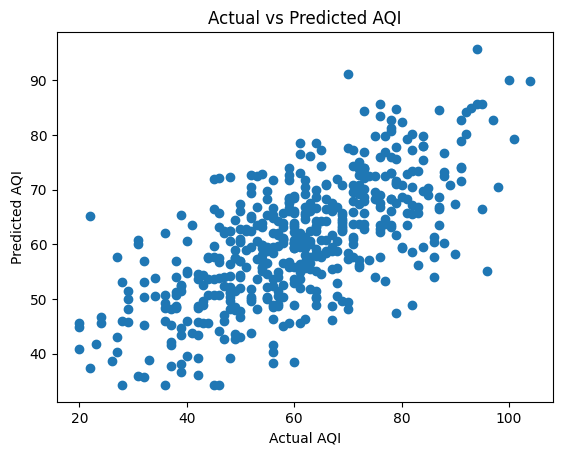

In [85]:
plt.scatter(
    data["Air_Quality_Index_AQI"],
    data["Predicted_AQI"]
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()

In [86]:
data["Residual"] = (
    data["Air_Quality_Index_AQI"] -
    data["Predicted_AQI"]
)

data[["Air_Quality_Index_AQI", "Predicted_AQI", "Residual"]].head()

,Air_Quality_Index_AQI,Predicted_AQI,Residual
0,83,66.887165,16.112835
1,55,49.914325,5.085675
2,71,69.573514,1.426486
3,86,53.943849,32.056151
4,32,50.280646,-18.280646


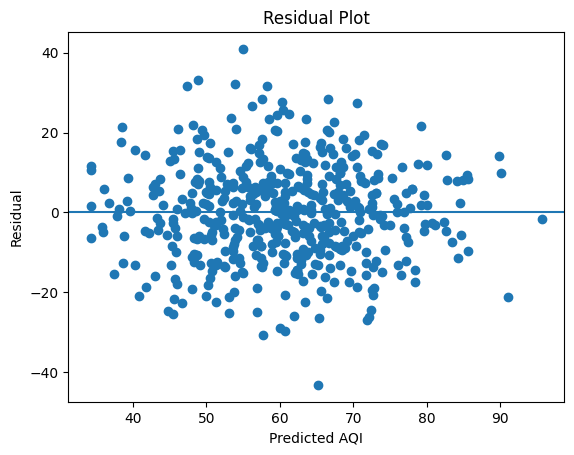

In [87]:
plt.scatter(data["Predicted_AQI"], data["Residual"])

plt.axhline(0)

plt.xlabel("Predicted AQI")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [88]:
correlation = data["PM2_5_ug_m3"].corr(
    data["Air_Quality_Index_AQI"]
)

print("Correlation:", correlation)

Correlation: 0.6764055938995733


In [89]:
corr = data[
    [
        "Temperature_C",
        "Humidity_percent",
        "Rainfall_mm",
        "Wind_Speed_kmh",
        "PM2_5_ug_m3",
        "PM10_ug_m3",
        "NO2_ug_m3",
        "Air_Quality_Index_AQI"
    ]
].corr()

print(corr)

                       Temperature_C  Humidity_percent  Rainfall_mm  \
Temperature_C               1.000000         -0.600579    -0.030305   
Humidity_percent           -0.600579          1.000000    -0.013949   
Rainfall_mm                -0.030305         -0.013949     1.000000   
Wind_Speed_kmh             -0.037806          0.017803    -0.023962   
PM2_5_ug_m3                 0.511934         -0.316548    -0.097946   
PM10_ug_m3                  0.405525         -0.248221    -0.132834   
NO2_ug_m3                   0.496174         -0.327187    -0.064846   
Air_Quality_Index_AQI       0.575869         -0.376288    -0.095129   

                       Wind_Speed_kmh  PM2_5_ug_m3  PM10_ug_m3  NO2_ug_m3  \
Temperature_C               -0.037806     0.511934    0.405525   0.496174   
Humidity_percent             0.017803    -0.316548   -0.248221  -0.327187   
Rainfall_mm                 -0.023962    -0.097946   -0.132834  -0.064846   
Wind_Speed_kmh               1.000000    -0.221819  

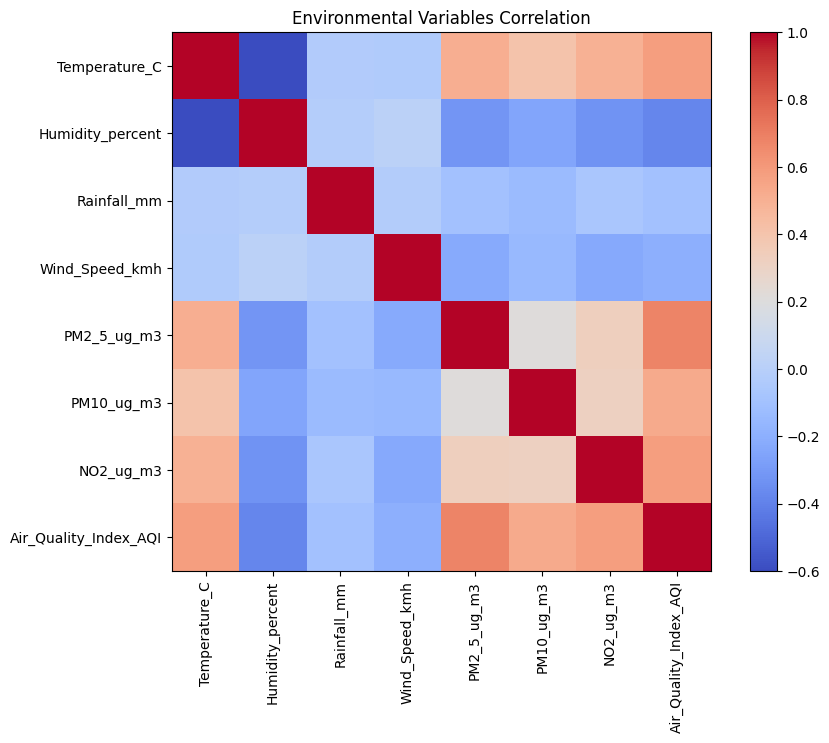

In [90]:
plt.figure(figsize=(10,7))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Environmental Variables Correlation")

plt.show()

In [91]:
print("----- FINAL RESULTS -----")

print("Correlation:", correlation)
print("Slope:", slope)
print("Intercept:", intercept)
print("R² Score:", r2)


----- FINAL RESULTS -----
Correlation: 0.6764055938995733
Slope: 1.221067604435731
Intercept: 28.179322090262332
R² Score: 0.4575245274586347


In [92]:
data.to_excel("environmental_analysis_results.xlsx", index=False)

print("File saved successfully!")

File saved successfully!
